# Presentation visualisation: Final Top100 segment distribution

Presentation-only visualisation of the existing official shortlist. This notebook reads the final Top100 and the existing industry mapping. It does not recompute ranking scores or write official recommendation tables.

The Top100 is distributed across all five segments, with no single segment dominating the shortlist. Counts describe selected merchants only, not market size, industry growth or future potential.

Run from the repository root or `member5_ranking/`. Exported PNG is 3600 × 2220 pixels (300 dpi); SVG uses vector paths for portable font appearance. Colours follow the supplied beige/navy slide reference. Full segment names wrap without abbreviation.


In [1]:
from pathlib import Path
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (cwd, *cwd.parents)
                    if (p / "member5_ranking/results/final_top_100.csv").is_file())
TOP100_PATH = PROJECT_ROOT / "member5_ranking/results/final_top_100.csv"
MAPPING_PATH = PROJECT_ROOT / "member3_industry_growth/results/category_to_group_mapping.csv"
RESULTS_DIR = PROJECT_ROOT / "member5_ranking/results"

top100 = pd.read_csv(TOP100_PATH, dtype={"merchant_abn": str})
mapping = pd.read_csv(MAPPING_PATH)
assert len(top100) == 100 and top100["merchant_abn"].is_unique
assert top100["final_rank"].between(1, 100).all()
selected = top100[["merchant_abn", "merchant_category"]].merge(
    mapping[["merchant_category", "industry_group"]],
    on="merchant_category", how="left", validate="many_to_one")
assert selected["industry_group"].notna().all()
# Alphabetical order breaks equal-count ties deterministically.
counts = selected.groupby("industry_group", sort=True).size().sort_values(
    ascending=False, kind="stable")
expected = {
    "Digital, Technology & Communications": 30,
    "Home, Garden & Living": 25,
    "Art, Gifts, Jewellery & Fashion": 16,
    "Mobility, Health & Specialist Services": 16,
    "Creative, Books & Leisure": 13,
}
assert counts.to_dict() == expected, "Official results changed: review slide figures before exporting."
assert counts.sum() == 100
print("Source:", TOP100_PATH)
print("Industry mapping:", MAPPING_PATH)
display(counts.rename("Selected merchants").to_frame())


Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/xiexinyu/.cache/fontconfig
	/Users/xiexinyu/.fontconfig


Matplotlib is building the font cache; this may take a moment.


Source: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/final_top_100.csv
Industry mapping: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member3_industry_growth/results/category_to_group_mapping.csv


,Selected merchants
industry_group,
"Digital, Technology & Communications",30
"Home, Garden & Living",25
"Art, Gifts, Jewellery & Fashion",16
"Mobility, Health & Specialist Services",16
"Creative, Books & Leisure",13


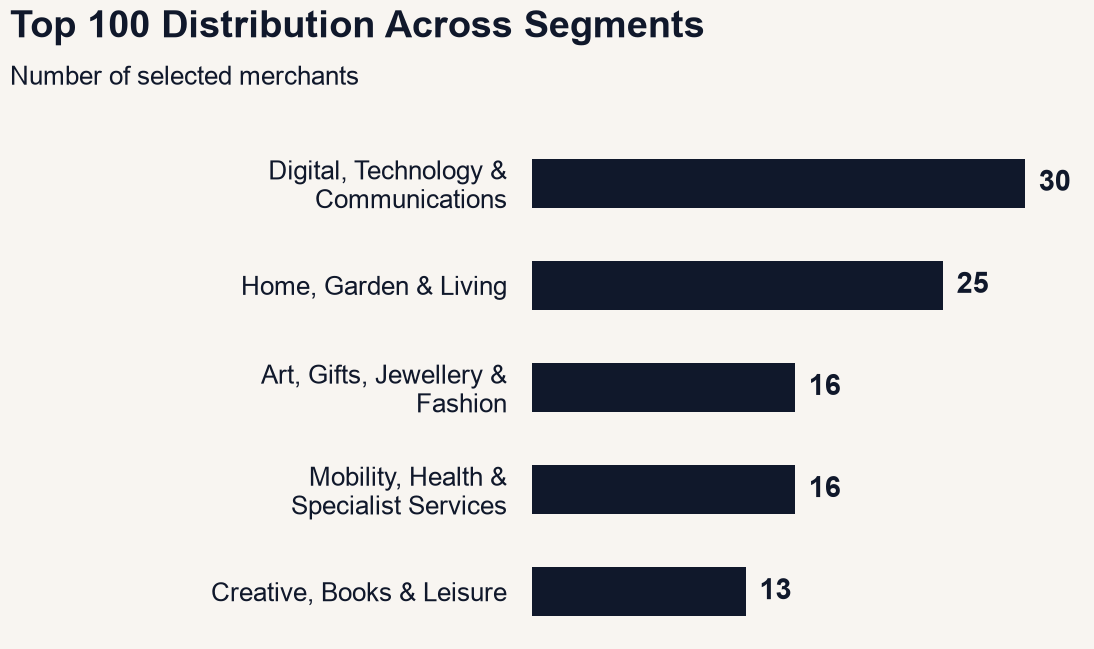

PNG: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/presentation_top100_segment_distribution.png
SVG: /Users/xiexinyu/Desktop/MAST30034-Project-2-Group-50/member5_ranking/results/presentation_top100_segment_distribution.svg


In [2]:
BEIGE = "#F8F5F1"
NAVY = "#10182B"
labels = [textwrap.fill(name, width=27, break_long_words=False,
                        break_on_hyphens=False) for name in counts.index]
PNG_PATH = RESULTS_DIR / "presentation_top100_segment_distribution.png"
SVG_PATH = RESULTS_DIR / "presentation_top100_segment_distribution.svg"

with plt.rc_context({"font.family": "Arial", "text.color": NAVY,
                     "ytick.color": NAVY, "svg.fonttype": "path"}):
    fig, ax = plt.subplots(figsize=(12, 7.4), facecolor=BEIGE)
    fig.subplots_adjust(left=0.49, right=0.95, top=0.76, bottom=0.08)
    ax.set_facecolor(BEIGE)
    bars = ax.barh(labels, counts.to_numpy(), color=NAVY, height=0.48)
    ax.invert_yaxis()
    ax.set_xlim(0, counts.max() * 1.12)
    ax.bar_label(bars, padding=10, fontsize=21, fontweight="bold", color=NAVY)
    ax.xaxis.set_visible(False)
    ax.tick_params(axis="y", length=0, pad=18, labelsize=19)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.text(0.055, 0.93, "Top 100 Distribution Across Segments",
             fontsize=27, fontweight="bold", ha="left", va="top")
    fig.text(0.055, 0.855, "Number of selected merchants",
             fontsize=19, ha="left", va="top")
    # SVG glyph paths preserve appearance even without Arial on the destination computer.
    fig.savefig(PNG_PATH, dpi=300, facecolor=BEIGE)
    fig.savefig(SVG_PATH, facecolor=BEIGE)
    plt.show()
    plt.close(fig)
print("PNG:", PNG_PATH)
print("SVG:", SVG_PATH)